# Part 2: Autodiff — Automatic Differentiation

**Goal**: Learn to compute exact gradients through arbitrary code with [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html). By the end, you'll differentiate through arbitrary Python functions, compute Jacobians and Hessians, and understand how JAX autodiff works under the hood.

---

## Table of Contents

1. **grad in 60 Seconds** — Differentiation as a function transformation
2. **What grad Actually Does** — The transformation model
3. **value_and_grad** — Loss and gradients in one pass
4. **Beyond Scalar Loss** — Jacobians, Hessians, custom derivatives
5. **Common Misconceptions**
6. **Capstone: Gradient Descent from Scratch**
7. **Summary — What To Do Next**

---

> **Prerequisites**: This notebook builds on **Notebook 01: Foundations**. You should be comfortable with JAX arrays and the immutability/purity model.

In [1]:
# @title Setup { display-mode: "form" }

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"JAX version: {jax.__version__}")
print(f"Devices:     {jax.devices()}")


JAX version: 0.9.2
Devices:     [CpuDevice(id=0)]


In [2]:
# @title Reconstruct MLP from Notebook 01 { display-mode: "form" }

def init_mlp_params(key, layer_sizes):
    """Initialize MLP parameters with He initialization."""
    params = []
    for i in range(len(layer_sizes) - 1):
        key, w_key, b_key = jax.random.split(key, 3)
        fan_in = layer_sizes[i]
        fan_out = layer_sizes[i + 1]
        w = jax.random.normal(w_key, (fan_in, fan_out)) * jnp.sqrt(2.0 / fan_in)
        b = jnp.zeros(fan_out)
        params.append((w, b))
    return params

def mlp_forward(params, x):
    """Forward pass through an MLP."""
    for i, (w, b) in enumerate(params):
        x = x @ w + b
        if i < len(params) - 1:
            x = jnp.maximum(x, 0)
    return x

# Same architecture and seed as Notebook 01
key = jax.random.PRNGKey(42)
layer_sizes = [8, 64, 32, 1]
params = init_mlp_params(key, layer_sizes)

print("MLP reconstructed: ", " → ".join(str(s) for s in layer_sizes))


MLP reconstructed:  8 → 64 → 32 → 1


---

# 1. grad in 60 Seconds

[`jax.grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) takes a function and returns a **new function** that computes the gradient.

```python
f  = lambda x: x ** 2    # A function
f' = jax.grad(f)          # Another function — the derivative
```

That's it. No `.backward()`, no tape, no graph object. Just function in, function out.

> **What kind of differentiation?** This is **automatic differentiation** (autodiff) — not symbolic differentiation (which manipulates math expressions like Wolfram Alpha) and not finite differences (which approximate `(f(x+ε) - f(x)) / ε`). Autodiff traces the actual computation your function performs and computes *exact* derivatives — to machine precision — in a single backward pass.

In [3]:
# A simple scalar function
def f(x):
    return x ** 3 - 2 * x ** 2 + x

# grad returns a NEW function
df = jax.grad(f)

# Which we can call like any function
x = 3.0
print(f"f({x})  = {f(x)}")       # 3^3 - 2*3^2 + 3 = 27 - 18 + 3 = 12
print(f"f'({x}) = {df(x)}")      # 3x^2 - 4x + 1 = 27 - 12 + 1 = 16

# Verify against the analytical derivative: f'(x) = 3x^2 - 4x + 1
analytical = 3 * x**2 - 4 * x + 1
print(f"\nAnalytical f'({x}) = {analytical}")
print(f"Match? {jnp.isclose(df(x), analytical)}")


f(3.0)  = 12.0
f'(3.0) = 16.0

Analytical f'(3.0) = 16.0
Match? True


In [4]:
def finite_difference(f, x, eps=1e-5):
    """Approximate derivative using central differences."""
    return (f(x + eps) - f(x - eps)) / (2 * eps)

# Compare across several points
print(f"{'x':>6} | {'grad(f)(x)':>12} | {'finite diff':>12} | {'error':>12}")
print("-" * 52)
for x_val in [-2.0, -1.0, 0.0, 1.0, 2.0, 3.0]:
    grad_val = df(x_val).item()
    fd_val = float(finite_difference(f, x_val))
    error = abs(grad_val - fd_val)
    print(f"{x_val:>6.1f} | {grad_val:>12.6f} | {fd_val:>12.6f} | {error:>12.2e}")

print("\ngrad is exact (to machine precision), not an approximation.")



     x |   grad(f)(x) |  finite diff |        error
----------------------------------------------------
  -2.0 |    21.000000 |    21.000000 |     2.71e-10
  -1.0 |     8.000000 |     8.000000 |     1.19e-10
   0.0 |     1.000000 |     1.000000 |     1.00e-10
   1.0 |     0.000000 |     0.000000 |     9.44e-11
   2.0 |     5.000000 |     5.000000 |     1.66e-10
   3.0 |    16.000000 |    16.000000 |     1.05e-10

grad is exact (to machine precision), not an approximation.


---

# 2. What grad Actually Does — The Transformation Model

When you call [`grad(f)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html), JAX doesn't symbolically differentiate your code. It doesn't approximate with finite differences. It performs **reverse-mode automatic differentiation** — it traces your function, builds a computation graph, and propagates derivatives backward through it.

The important insight: since [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) returns a function, you can apply [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) to *that* function to get higher-order derivatives.


In [5]:
# f(x) = sin(x)
# f'(x) = cos(x)
# f''(x) = -sin(x)
# f'''(x) = -cos(x)
# f''''(x) = sin(x)   ← back to the start

f = jnp.sin
df = jax.grad(f)
ddf = jax.grad(df)
dddf = jax.grad(ddf)
ddddf = jax.grad(dddf)

x = 1.0
print("Successive derivatives of sin(x) at x = 1.0:")
print(f"  f(x)      = {f(x):.6f}     (sin)")
print(f"  f'(x)     = {df(x):.6f}     (cos)")
print(f"  f''(x)    = {ddf(x):.6f}    (-sin)")
print(f"  f'''(x)   = {dddf(x):.6f}   (-cos)")
print(f"  f''''(x)  = {ddddf(x):.6f}    (sin again)")
print(f"\n  Full circle? {jnp.isclose(f(x), ddddf(x))}")



Successive derivatives of sin(x) at x = 1.0:
  f(x)      = 0.841471     (sin)
  f'(x)     = 0.540302     (cos)
  f''(x)    = -0.841471    (-sin)
  f'''(x)   = -0.540302   (-cos)
  f''''(x)  = 0.841471    (sin again)

  Full circle? True


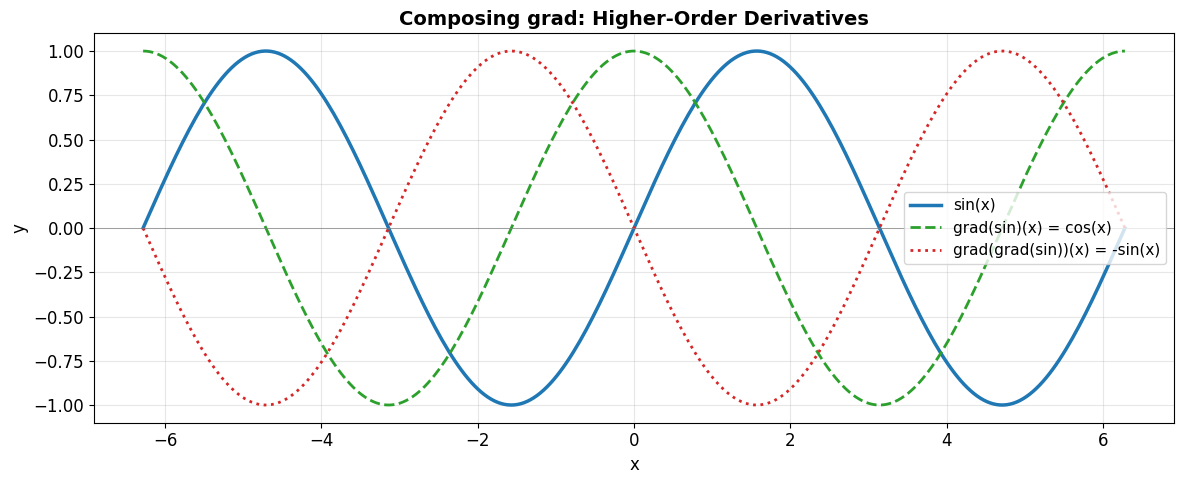

grad(grad(sin)) gives -sin — no symbolic algebra needed, just function composition.


In [6]:
# @title Visualize: Function and Its Derivatives { display-mode: "form" }

x = jnp.linspace(-2 * jnp.pi, 2 * jnp.pi, 300)

# Compute derivatives at each point (grad works on scalars, so we vmap)
f = jnp.sin
df = jax.grad(f)
ddf = jax.grad(df)

# vmap lets us apply a scalar function across an array (preview of Notebook 04)
y0 = jax.vmap(f)(x)
y1 = jax.vmap(df)(x)
y2 = jax.vmap(ddf)(x)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, y0, label="sin(x)", linewidth=2.5, color='#1f77b4')
ax.plot(x, y1, label="grad(sin)(x) = cos(x)", linewidth=2, color='#2ca02c', linestyle='--')
ax.plot(x, y2, label="grad(grad(sin))(x) = -sin(x)", linewidth=2, color='#d62728', linestyle=':')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Composing grad: Higher-Order Derivatives', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("grad(grad(sin)) gives -sin — no symbolic algebra needed, just function composition.")



## Differentiating with Respect to Multiple Arguments

By default, [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) differentiates with respect to the **first** argument. Use `argnums` to change this.


In [7]:
def weighted_sum(w, x, b):
    return jnp.sum(w * x) + b

w = jnp.array([1.0, 2.0, 3.0])
x = jnp.array([4.0, 5.0, 6.0])
b = 10.0

# Gradient w.r.t. first arg (w) — default
dw = jax.grad(weighted_sum, argnums=0)(w, x, b)
print(f"d/dw = {dw}  (should be x = [4, 5, 6])")

# Gradient w.r.t. second arg (x)
dx = jax.grad(weighted_sum, argnums=1)(w, x, b)
print(f"d/dx = {dx}  (should be w = [1, 2, 3])")

# Gradient w.r.t. third arg (b)
db = jax.grad(weighted_sum, argnums=2)(w, x, b)
print(f"d/db = {db}  (should be 1.0)")

# Multiple at once
dw, dx = jax.grad(weighted_sum, argnums=(0, 1))(w, x, b)
print(f"\nBoth: dw={dw}, dx={dx}")



d/dw = [4. 5. 6.]  (should be x = [4, 5, 6])
d/dx = [1. 2. 3.]  (should be w = [1, 2, 3])
d/db = 1.0  (should be 1.0)

Both: dw=[4. 5. 6.], dx=[1. 2. 3.]


---

# 3. value_and_grad — Getting Loss and Gradients in One Pass

In practice, you almost always want both the loss value *and* its gradients. [`jax.value_and_grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.value_and_grad.html) computes both in a single forward+backward pass — more efficient than calling the function and its gradient separately.

> **Why not two separate calls?** `f(x)` followed by `grad(f)(x)` runs the forward pass twice. `value_and_grad` runs it once and piggybacks the value on the backward pass — half the work for the same result.


In [8]:
def mse_loss(params, x, y):
    """Mean squared error loss."""
    pred = mlp_forward(params, x)
    return jnp.mean((pred - y) ** 2)

# Generate some synthetic data
key = jax.random.PRNGKey(0)
key, x_key, noise_key = jax.random.split(key, 3)
x_sample = jax.random.normal(x_key, (8,))
y_sample = jnp.array(1.5)  # Target

# Compute loss AND gradients in one call
loss_val, grads = jax.value_and_grad(mse_loss)(params, x_sample, y_sample)

print(f"Loss: {loss_val:.6f}")
print(f"\nGradient structure (mirrors params):")
for i, (dw, db) in enumerate(grads):
    print(f"  Layer {i}: dw shape {dw.shape}, db shape {db.shape}")

print("\nThe gradient has the SAME structure as the params.")
print("This is a preview of pytrees — covered properly in Notebook 05.")



Loss: 0.796815

Gradient structure (mirrors params):
  Layer 0: dw shape (8, 64), db shape (64,)
  Layer 1: dw shape (64, 32), db shape (32,)
  Layer 2: dw shape (32, 1), db shape (1,)

The gradient has the SAME structure as the params.
This is a preview of pytrees — covered properly in Notebook 05.


## has_aux: Returning Extra Information

Sometimes you want the loss function to return additional outputs (predictions, intermediate values). Use `has_aux=True` to tell JAX that the function returns `(loss, auxiliary_data)` and only differentiate the loss.


> **Mental model**: `has_aux=True` tells `grad` that your function returns `(loss, extras)`. `grad` differentiates only through `loss` and passes `extras` back to you unchanged — they don't affect the gradient computation.


In [9]:
def loss_with_predictions(params, x, y):
    """Returns (loss, predictions) — grad only applies to loss."""
    pred = mlp_forward(params, x)
    loss = jnp.mean((pred - y) ** 2)
    return loss, pred  # pred is auxiliary data

# has_aux=True tells JAX the second return value isn't part of the loss
(loss_val, pred), grads = jax.value_and_grad(loss_with_predictions, has_aux=True)(
    params, x_sample, y_sample
)

print(f"Loss:       {loss_val:.6f}")
print(f"Prediction: {pred.item():.6f}")
print(f"Target:     {y_sample.item():.6f}")
print(f"\nGradients computed w.r.t. loss only, pred passed through unchanged.")



Loss:       0.796815
Prediction: 2.392645
Target:     1.500000

Gradients computed w.r.t. loss only, pred passed through unchanged.


---

# 4. Beyond Scalar Loss — Jacobians, Hessians, and Custom Derivatives

[`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) requires a **scalar** output. For vector-valued functions, JAX provides `jacobian` and `hessian`. For functions where automatic differentiation gives numerically unstable results, you can define **custom derivatives**.

## Jacobians

The Jacobian is the matrix of all partial derivatives. For a function `f: R^n → R^m`, the Jacobian is an `m × n` matrix.


In [10]:
def f_vector(x):
    """R^3 → R^2"""
    return jnp.array([
        x[0] * x[1],      # x0 * x1
        x[1] ** 2 + x[2],  # x1^2 + x2
    ])

x = jnp.array([2.0, 3.0, 1.0])

# Full Jacobian
J = jax.jacobian(f_vector)(x)
print("Jacobian (2x3):")
print(J)
print(f"\nJ[0,0] = d(x0*x1)/dx0 = x1 = {x[1]}  ✓")
print(f"J[0,1] = d(x0*x1)/dx1 = x0 = {x[0]}  ✓")
print(f"J[1,1] = d(x1²+x2)/dx1 = 2*x1 = {2*x[1]}  ✓")
print(f"J[1,2] = d(x1²+x2)/dx2 = 1  ✓")



Jacobian (2x3):
[[3. 2. 0.]
 [0. 6. 1.]]

J[0,0] = d(x0*x1)/dx0 = x1 = 3.0  ✓
J[0,1] = d(x0*x1)/dx1 = x0 = 2.0  ✓
J[1,1] = d(x1²+x2)/dx1 = 2*x1 = 6.0  ✓
J[1,2] = d(x1²+x2)/dx2 = 1  ✓


In [11]:
def g(x):
    """A scalar function of a vector — R^3 → R"""
    return x[0]**2 * x[1] + jnp.sin(x[2])

x = jnp.array([1.0, 2.0, 3.0])

H = jax.hessian(g)(x)
print("Hessian (3x3) — matrix of second derivatives:")
print(H)
print(f"\nH[0,0] = d²/dx0² (x0²*x1) = 2*x1 = {2*x[1]:.1f}  ✓")
print(f"H[0,1] = d²/dx0dx1 (x0²*x1) = 2*x0 = {2*x[0]:.1f}  ✓")
print(f"H[2,2] = d²/dx2² (sin(x2)) = -sin(x2) = {-jnp.sin(x[2]):.4f}  ✓")



Hessian (3x3) — matrix of second derivatives:
[[ 4.       2.       0.     ]
 [ 2.       0.       0.     ]
 [ 0.       0.      -0.14112]]

H[0,0] = d²/dx0² (x0²*x1) = 2*x1 = 4.0  ✓
H[0,1] = d²/dx0dx1 (x0²*x1) = 2*x0 = 2.0  ✓
H[2,2] = d²/dx2² (sin(x2)) = -sin(x2) = -0.1411  ✓


## Forward Mode vs. Reverse Mode

JAX supports both:

| Mode | Function | Best When |
|---|---|---|
| **Reverse** (`vjp`, [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html)) | Few outputs, many inputs | Loss functions, most ML |
| **Forward** (`jvp`) | Few inputs, many outputs | Physics simulations, Jacobian columns |

Rule of thumb: if your function maps `R^n → R^1` (a loss function), reverse mode is O(1) backward passes regardless of n. If it maps `R^1 → R^m`, forward mode is O(1) forward passes.


## Custom Derivatives

Sometimes the automatic derivative is numerically unstable even though a stable formula exists. `@custom_jvp` lets you teach JAX a better derivative.


In [12]:
# log(1 + exp(x)) — the "softplus" function
# Naive implementation overflows for large x (exp(100) = inf)

def naive_log1pexp(x):
    return jnp.log(1 + jnp.exp(x))

# The custom, stable version
@jax.custom_jvp
def stable_log1pexp(x):
    return jnp.log(1 + jnp.exp(x))

@stable_log1pexp.defjvp
def stable_log1pexp_jvp(primals, tangents):
    (x,), (t,) = primals, tangents
    # d/dx log(1+exp(x)) = sigmoid(x) = 1/(1+exp(-x))
    # This is stable for all x
    return stable_log1pexp(x), t * jax.nn.sigmoid(x)

# Compare at x = 100.0 (where exp(100) overflows)
x = 100.0
print(f"x = {x}")
print(f"  Naive f(x):  {naive_log1pexp(x)}")
print(f"  Naive f'(x): {jax.grad(naive_log1pexp)(x)}")
print(f"  Stable f(x): {stable_log1pexp(x)}")
print(f"  Stable f'(x): {jax.grad(stable_log1pexp)(x)}")
print(f"\nExpected f'(100) ≈ 1.0 (sigmoid(100) ≈ 1)")
print("The naive gradient is NaN; the custom one is correct.")



x = 100.0
  Naive f(x):  inf
  Naive f'(x): nan
  Stable f(x): inf
  Stable f'(x): 1.0

Expected f'(100) ≈ 1.0 (sigmoid(100) ≈ 1)
The naive gradient is NaN; the custom one is correct.


---

# 5. Common Misconceptions

## Misconception: "grad is symbolic differentiation"

Symbolic differentiation (like Wolfram Alpha) manipulates mathematical expressions. JAX's [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) transforms *programs* — it traces the actual computation your function performs and builds a backward pass through it. This is why [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) works on arbitrary Python code (loops, function calls, conditionals via `lax.cond`) — it differentiates the *execution path*, not a formula.


## Misconception: "Autodiff is approximate"

Automatic differentiation computes *exact* derivatives (to machine precision). It is not finite differences. The only approximation is floating-point arithmetic itself — the same approximation that affects every numerical computation. If [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) gives you a wrong answer, it's almost always because your function has a discontinuity or a numerical stability issue (where custom derivatives help).


---

# 6. Capstone: Gradient Descent from Scratch

Let's take the MLP from [Notebook 01](01_foundations.ipynb) and run gradient descent — *without* JIT — to see that autodiff alone is sufficient. We'll time it too, so Notebook 03 can show the speedup from compilation.

In [13]:
# @title Generate Synthetic Regression Data { display-mode: "form" }

def generate_data(key, n_samples=500, noise_scale=0.1):
    """Generate y = sin(x_0) + 0.5*cos(x_1) + noise, with 8 input features."""
    key, x_key, noise_key = jax.random.split(key, 3)
    x = jax.random.normal(x_key, (n_samples, 8))
    # Target depends on first two features only — the network must learn to ignore the rest
    y = jnp.sin(x[:, 0]) + 0.5 * jnp.cos(x[:, 1]) + noise_scale * jax.random.normal(noise_key, (n_samples,))
    return x, y

key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)
x_train, y_train = generate_data(data_key)

print(f"Training data: x shape {x_train.shape}, y shape {y_train.shape}")
print(f"Target range: [{y_train.min().item():.2f}, {y_train.max().item():.2f}]")



Training data: x shape (500, 8), y shape (500,)
Target range: [-1.47, 1.67]


In [14]:
def mse_loss(params, x, y):
    """Batched MSE: average over all samples."""
    # Apply forward pass to each sample (simple loop — vmap version in Notebook 04)
    preds = jnp.array([mlp_forward(params, xi) for xi in x]).squeeze()  # .squeeze() strips out dangling length-1 dimensions
    return jnp.mean((preds - y) ** 2)

# The @ decorator tells Python to pass this through jax.jit() implicitly
@jax.jit
def train_step(params, x, y, lr=0.01):
    """One step of gradient descent.

    Returns:
        (updated_params, loss_value)
    """
    loss, grads = jax.value_and_grad(mse_loss)(params, x, y)

    # SGD update: param = param - lr * gradient
    # This works because grads has the same structure as params
    new_params = [
        (w - lr * dw, b - lr * db)
        for (w, b), (dw, db) in zip(params, grads)  # zip() structurally pairs the lists
    ]

    return new_params, loss

# Verify it works (and trigger compilation)
new_params, loss = train_step(params, x_train, y_train)
print(f"Initial loss: {loss.item():.4f}")
print(f"Params structure preserved: {[w.shape for w, b in new_params]}")



Initial loss: 3.2752
Params structure preserved: [(8, 64), (64, 32), (32, 1)]


In [15]:
# @title Train the MLP { display-mode: "form" }

# Re-initialize
key = jax.random.PRNGKey(42)
params = init_mlp_params(key, [8, 64, 32, 1])

# Training loop
n_epochs = 300
losses = []

for epoch in range(n_epochs):
    params, loss = train_step(params, x_train, y_train, lr=0.005)
    losses.append(loss.item())

    if epoch % 50 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:>3d}: loss = {loss.item():.4f}")



Epoch   0: loss = 3.2752
Epoch  50: loss = 0.3377
Epoch 100: loss = 0.2317
Epoch 150: loss = 0.1817
Epoch 200: loss = 0.1537
Epoch 250: loss = 0.1350
Epoch 299: loss = 0.1222


---

# 7. Summary — What To Do Next

## Key Takeaways

1. **[`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) is a function transformation** — it takes a function and returns a new function that computes the gradient. No tape, no `.backward()`, no graph objects.

2. **[`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) composes** — `grad(grad(f))` gives you second derivatives. This works because `grad` returns an ordinary function that `grad` can transform again.

3. **[`value_and_grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.value_and_grad.html)** computes loss and gradients in a single forward+backward pass. Use `has_aux=True` when your function returns extra outputs alongside the loss.

4. **Autodiff is exact** — not finite differences, not symbolic. It traces the actual computation and propagates exact derivatives to machine precision.

5. **[`jax.jacobian`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jacobian.html) and [`jax.hessian`](https://jax.readthedocs.io/en/latest/_autosummary/jax.hessian.html)** extend `grad` to vector-valued functions and second derivatives.

## What's Next

In **Notebook 03: JIT Compilation**, we'll:
- Take the training loop from this notebook and compile it with `@jax.jit`
- Measure the speedup (typically 10-100x on real workloads)
- Learn when JIT breaks and how to fix it

The training step you built here is correct but slow — every JAX operation dispatches separately to the device. JIT eliminates that overhead.

---

# Exercises

1. **Higher-order gradients**: Use `jax.grad(jax.grad(f))` to compute the second derivative of `f(x) = x³ - 2x² + x`. Verify the result at `x = 3.0` by hand.

2. **Differentiating with respect to non-first argument**: Write a function `f(a, b, c) = a * b + c`. Use `argnums=(0, 1)` to get gradients with respect to both `a` and `b` simultaneously.

3. **Custom derivative**: Write a numerically stable version of `log(1 + exp(x))` (softplus) using `@jax.custom_vjp`. Verify that the gradient is correct for large positive inputs where the naive implementation overflows.